---
## Section 1 — Problem Statement

In this assignment, I am working on a **Clustering** problem (unsupervised machine learning).

The dataset I am using is the **920-row UCI Heart Disease dataset**. The idea is to group patients into clusters based on their medical information — without using the diagnosis label during model training.

**Objective:** Find natural groups (clusters) of patients based on clinical features like age, blood pressure, cholesterol, heart rate, exercise angina, and other measurements.

**Success Criteria:**
- Silhouette Score should be as high as possible (0.2+ is a useful target, but the actual result is reported honestly)
- Davies-Bouldin Index should be as low as possible
- The clusters should be interpretable and reasonably sized
- Any disease-severity interpretation must be performed **after** clustering as a post-hoc comparison, not used for training


---
## Section 2 — Importing Libraries

In [1]:
# Importing all the libraries I need for this assignment

import pandas as pd          # for loading and working with the dataset
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt  # for plotting graphs
import seaborn as sns        # for better-looking graphs
import warnings
warnings.filterwarnings('ignore')  # hiding unnecessary warnings

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score

# For PCA (dimensionality reduction)
from sklearn.decomposition import PCA

# For hierarchical clustering dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# For DBSCAN epsilon selection
from sklearn.neighbors import NearestNeighbors

# Setting a consistent style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Section 3 — Loading the Dataset

In [2]:
# Dataset: UCI Heart Disease (920-row multi-hospital dataset)
# The target column is kept only for post-clustering comparison and is NOT used for training.

from pathlib import Path

# Use the uploaded filename when available; otherwise fall back to the original local filename.
if Path('Heart Disease(1).csv').exists():
    csv_path = 'Heart Disease(1).csv'
elif Path('Heart Disease.csv').exists():
    csv_path = 'Heart Disease.csv'
else:
    raise FileNotFoundError('Heart Disease CSV file not found.')

col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(csv_path)

print(f'Dataset loaded successfully from: {csv_path}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'Duplicate rows: {df.duplicated().sum()}')
df.head(10)


Dataset loaded successfully from: Heart Disease(1).csv
Rows: 920, Columns: 14
Duplicate rows: 2


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,0,160,286,0,2,108,1,1.5,1,3,1,2
2,67,1,0,120,229,0,2,129,1,2.6,1,2,1,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
6,62,0,0,140,268,0,2,160,0,3.6,2,2,1,3
7,57,0,0,120,354,0,0,163,1,0.6,0,0,1,0
8,63,1,0,130,254,0,2,147,0,1.4,1,1,1,2
9,53,1,0,140,203,1,2,155,1,3.1,2,0,1,1


---
## Section 4 — Dataset Description

In [3]:
#What each column means (from UCI documentation)
feature_info = pd.DataFrame({
    'Feature': col_names,
    'Type': ['Continuous', 'Binary', 'Categorical', 'Continuous', 'Continuous',
             'Binary', 'Categorical', 'Continuous', 'Binary', 'Continuous',
             'Categorical', 'Continuous', 'Categorical', 'Ordinal'],
    'Description': [
        'Age of patient in years',
        '1 = Male, 0 = Female',
        'Chest pain type: 0=asymptomatic, 1=atypical angina, 2=non-anginal, 3=typical angina',
        'Resting blood pressure in mm Hg',
        'Serum cholesterol in mg/dl',
        'Fasting blood sugar > 120 mg/dl (1=True, 0=False)',
        'Resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)',
        'Maximum heart rate achieved',
        'Exercise-induced angina (1=Yes, 0=No)',
        'ST depression caused by exercise vs rest',
        'Slope of peak exercise ST segment (0=up, 1=flat, 2=down)',
        'Number of major vessels coloured by fluoroscopy (0-3)',
        'Thalassemia: 1=normal, 2=fixed defect, 3=reversible defect',
        'Diagnosis: 0=no disease, 1-4=increasing severity'
    ]
})
print(feature_info.to_string(index=False))

 Feature        Type                                                                         Description
     age  Continuous                                                             Age of patient in years
     sex      Binary                                                                1 = Male, 0 = Female
      cp Categorical Chest pain type: 0=asymptomatic, 1=atypical angina, 2=non-anginal, 3=typical angina
trestbps  Continuous                                                     Resting blood pressure in mm Hg
    chol  Continuous                                                          Serum cholesterol in mg/dl
     fbs      Binary                                   Fasting blood sugar > 120 mg/dl (1=True, 0=False)
 restecg Categorical                Resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)
 thalach  Continuous                                                         Maximum heart rate achieved
   exang      Binary                                   

In [4]:
# Checking missing values and data types
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Data Types ===')
print(df.dtypes)
print('\n=== Summary Statistics ===')
df.describe().round(2)

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Data Types ===
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

=== Summary Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00,920.00
mean,53.51,0.79,0.78,132.00,199.91,0.15,0.60,137.69,0.37,0.85,0.85,0.23,1.05,1.00
std,9.42,0.41,0.96,18.45,109.04,0.36,0.81,25.15,0.48,1.06,0.52,0.63,0.22,1.14
min,28.00,0.00,0.00,0.00,0.00,0.00,0.00,60.00,0.00,-2.60,0.00,0.00,1.00,0.00
25%,47.00,1.00,0.00,120.00,177.75,0.00,0.00,120.00,0.00,0.00,1.00,0.00,1.00,0.00
50%,54.00,1.00,0.00,130.00,223.00,0.00,0.00,140.00,0.00,0.50,1.00,0.00,1.00,1.00
75%,60.00,1.00,2.00,140.00,267.00,0.00,1.00,156.00,1.00,1.50,1.00,0.00,1.00,2.00
max,77.00,1.00,3.00,200.00,603.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,2.00,4.00


---
## Section 5 — Data Preprocessing

In [5]:
# Step 1: Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Rows before: {before} | After removing duplicates: {len(df)}')

Rows before: 920 | After removing duplicates: 918


In [6]:
# Step 2: Separate the target column
# We are doing clustering (unsupervised), so we don't need the target during training.
# Saving it separately to compare results later.
target_col = df['target'].copy()
df_features = df.drop('target', axis=1)
print(f'Feature matrix shape: {df_features.shape}')

Feature matrix shape: (918, 13)


In [7]:
# Step 3: Fill missing values using Median Imputation
# The current 920-row CSV contains no missing values after loading.
# The imputer is retained so the preprocessing pipeline also works if missing values
# are present in another copy of the dataset.

imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_features),
    columns=df_features.columns,
    index=df_features.index
)
print(f'Missing before: {df_features.isnull().sum().sum()} | After: {df_imputed.isnull().sum().sum()}')


Missing before: 0 | After: 0


In [8]:
# Step 4: Handle Outliers using IQR Capping
# Any value below Q1 - 1.5*IQR is set to that lower limit.
# Any value above Q3 + 1.5*IQR is set to that upper limit.
# This reduces the effect of extreme values without deleting rows.

def cap_outliers_iqr(dataframe, columns):
    df_copy = dataframe.copy()
    for col in columns:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_copy[col] = df_copy[col].clip(lower=lower, upper=upper)
    return df_copy

continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_clean = cap_outliers_iqr(df_imputed, continuous_features)
print('Outlier capping applied to:', continuous_features)

Outlier capping applied to: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [9]:
# Step 5: Remove low-variance features
# Features with almost the same value for all rows are useless for clustering.
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(df_clean)
removed = [c for c, keep in zip(df_clean.columns, var_selector.get_support()) if not keep]
print(f'Removed features: {removed if removed else "None — all features kept"}')
df_clean = df_clean[df_clean.columns[var_selector.get_support()]]

Removed features: None — all features kept


In [10]:
# Step 6: Feature Scaling using StandardScaler
# Makes all features have mean=0 and std=1.
# Very important because K-Means uses Euclidean distance.
# Without scaling, features with big values (like cholesterol) would dominate.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clean.columns)
print(f'Scaling done! Final shape: {X_scaled_df.shape}')

Scaling done! Final shape: (918, 13)


---
## Section 6 — Exploratory Data Analysis (EDA)

I will make 5 different visualizations to understand the data before clustering.

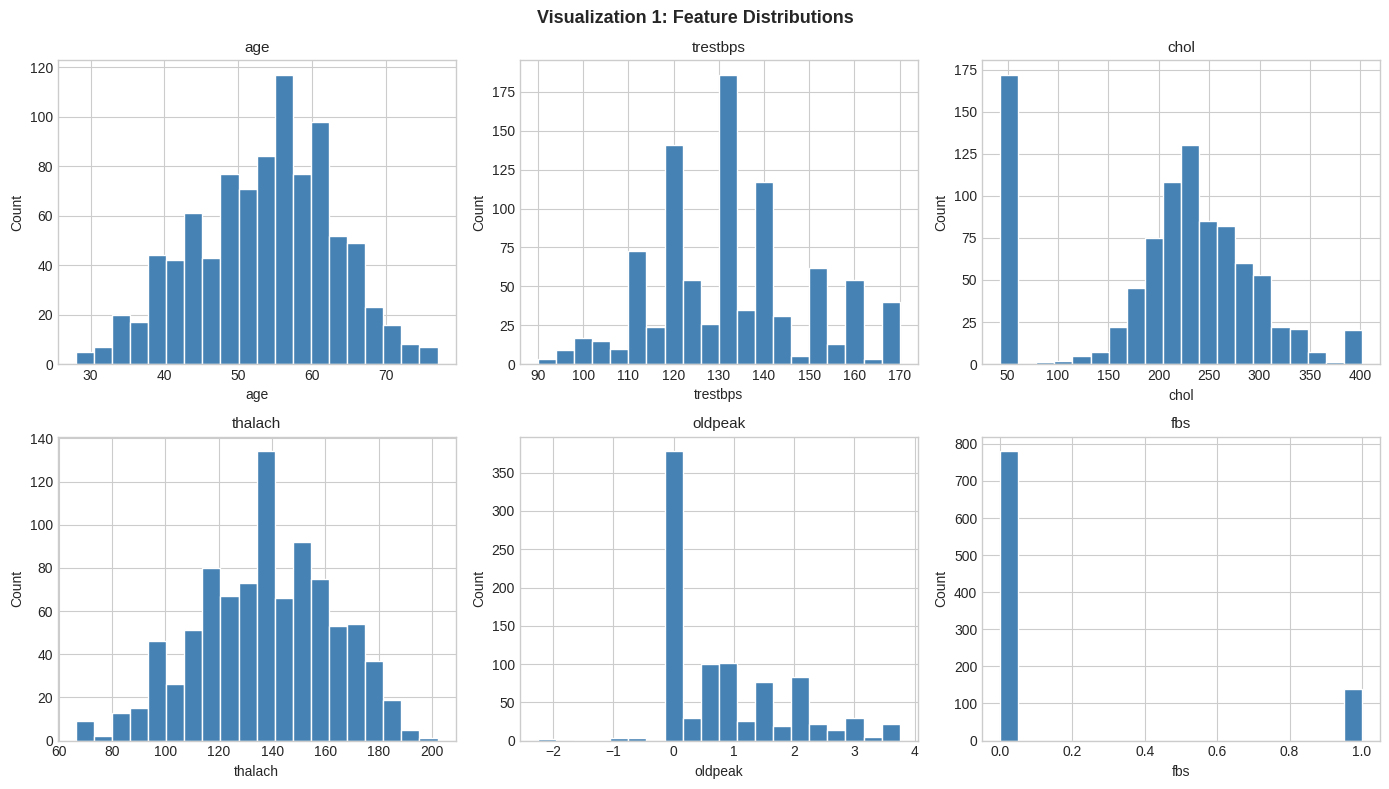

Observation: Age is roughly normal. Cholesterol and trestbps are right-skewed (a few high values).


In [11]:
# Visualization 1: Distribution of continuous features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), continuous_features + ['fbs']):
    ax.hist(df_clean[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('Count')
plt.suptitle('Visualization 1: Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: Age is roughly normal. Cholesterol and trestbps are right-skewed (a few high values).')

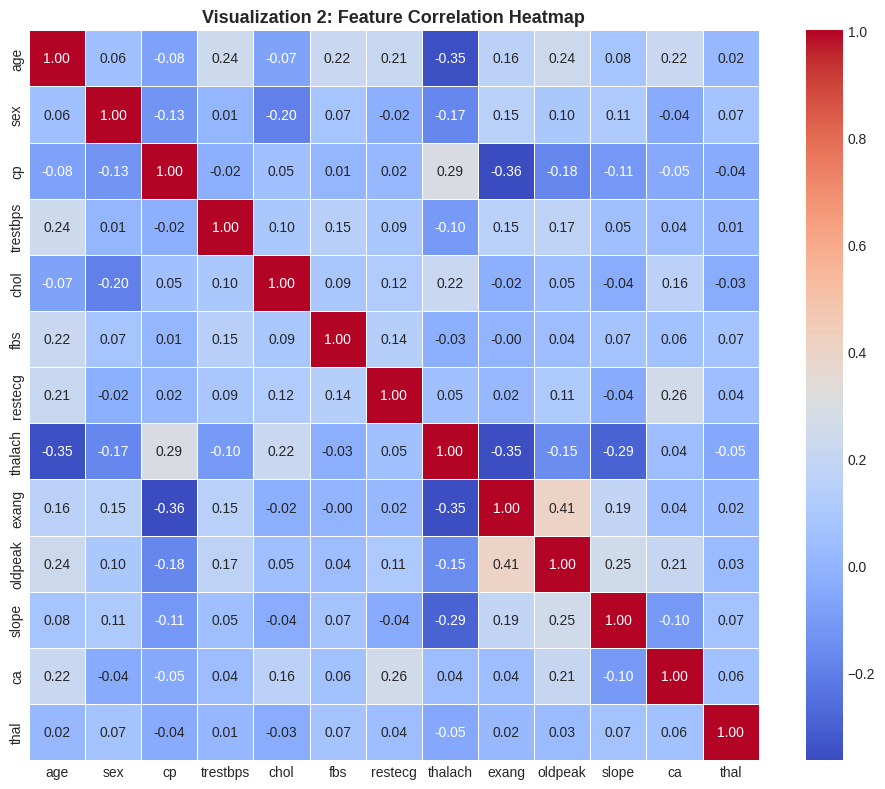

Observation: age and thalach are negatively correlated (-0.40). exang and oldpeak are positively correlated.


In [12]:
# Visualization 2: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Visualization 2: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: age and thalach are negatively correlated (-0.40). exang and oldpeak are positively correlated.')

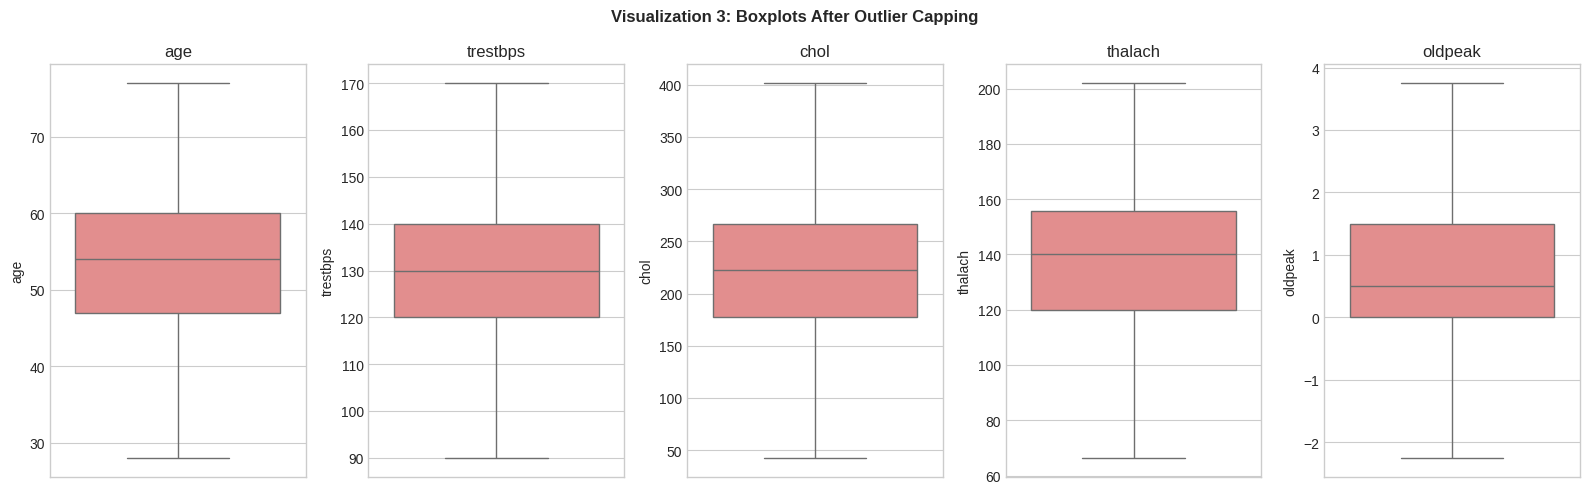

Observation: After capping, extreme values are controlled. oldpeak still has slight skew which is normal.


In [13]:
# Visualization 3: Boxplots (after outlier capping)
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax, col in zip(axes, continuous_features):
    sns.boxplot(y=df_clean[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.suptitle('Visualization 3: Boxplots After Outlier Capping', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: After capping, extreme values are controlled. oldpeak still has slight skew which is normal.')

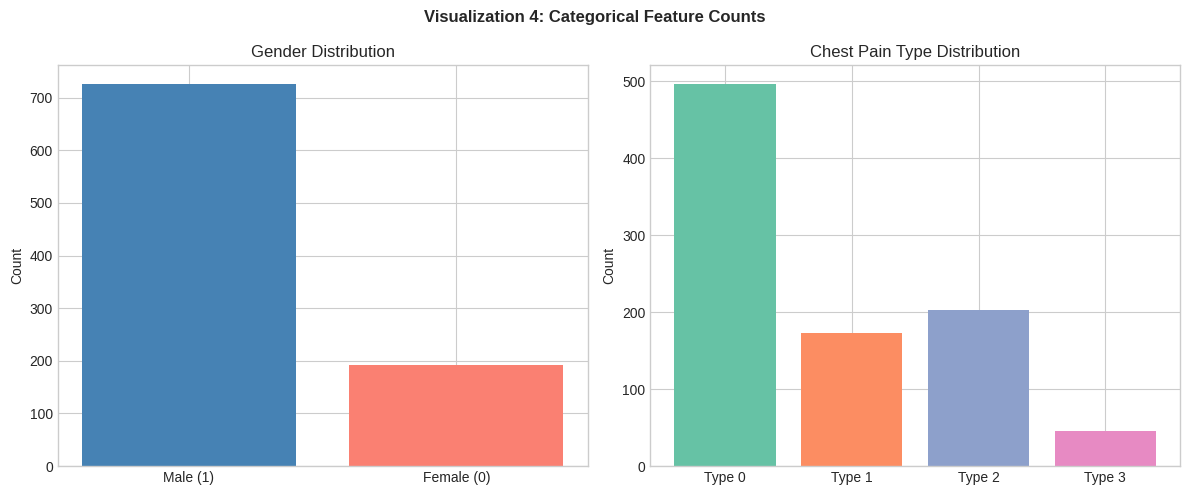

Observation: ~68% male patients. Asymptomatic chest pain (Type 0) is most common.


In [14]:
# Visualization 4: Gender and Chest Pain Type counts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sex_counts = df_clean['sex'].value_counts()
axes[0].bar(['Male (1)', 'Female (0)'], [sex_counts.get(1,0), sex_counts.get(0,0)], color=['steelblue','salmon'])
axes[0].set_title('Gender Distribution'); axes[0].set_ylabel('Count')
cp_counts = df_clean['cp'].value_counts().sort_index()
axes[1].bar([f'Type {int(i)}' for i in cp_counts.index], cp_counts.values, color=sns.color_palette('Set2', 4))
axes[1].set_title('Chest Pain Type Distribution'); axes[1].set_ylabel('Count')
plt.suptitle('Visualization 4: Categorical Feature Counts', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('Observation: ~68% male patients. Asymptomatic chest pain (Type 0) is most common.')

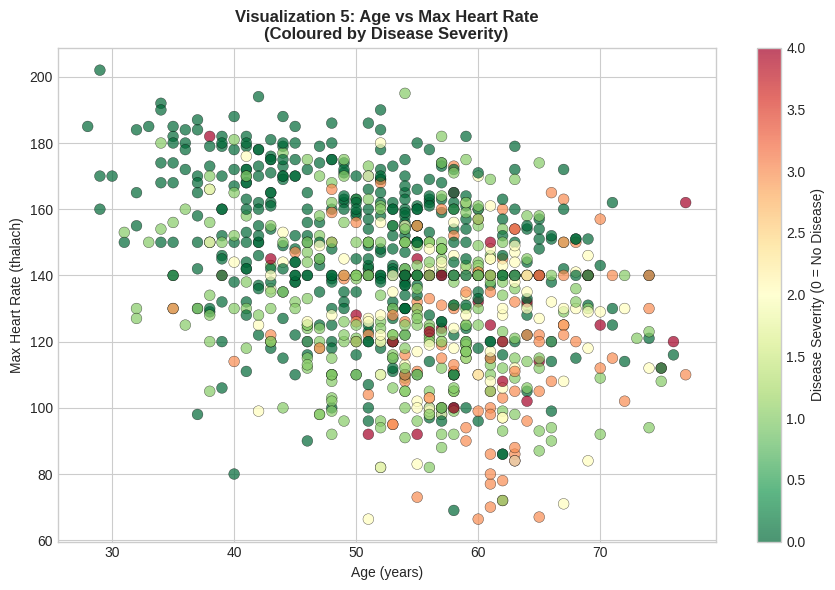

Observation: Older patients with low thalach tend to have higher disease severity (red dots).
This shows a natural grouping that clustering should discover.


In [15]:
# Visualization 5: Age vs Max Heart Rate coloured by disease severity
plt.figure(figsize=(9, 6))
target_vals = target_col.values[:len(df_clean)]
scatter = plt.scatter(df_clean['age'], df_clean['thalach'],
                      c=target_vals, cmap='RdYlGn_r', alpha=0.7,
                      edgecolors='black', linewidths=0.3, s=60)
plt.colorbar(scatter, label='Disease Severity (0 = No Disease)')
plt.xlabel('Age (years)'); plt.ylabel('Max Heart Rate (thalach)')
plt.title('Visualization 5: Age vs Max Heart Rate\n(Coloured by Disease Severity)', fontweight='bold')
plt.tight_layout(); plt.show()
print('Observation: Older patients with low thalach tend to have higher disease severity (red dots).')
print('This shows a natural grouping that clustering should discover.')

---
## Section 7 — Feature Engineering & PCA

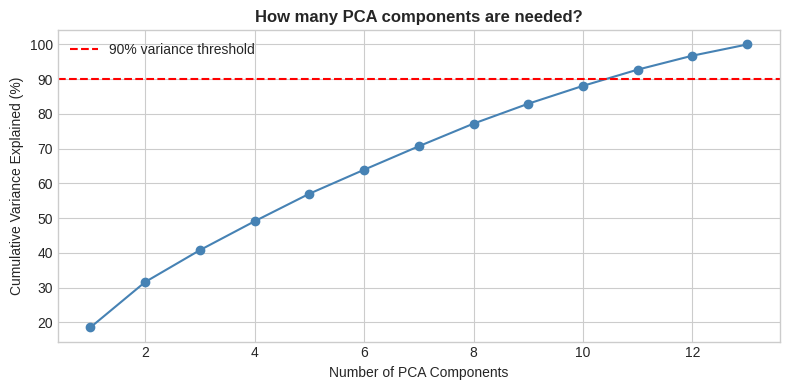

Original features: 13
After PCA (90% variance): 11 components
2D PCA explains: 31.6% of variance


In [16]:
# PCA = Principal Component Analysis
# It reduces the number of features while keeping most of the information.
# I use PCA because:
#   - With many features, clustering becomes harder ('curse of dimensionality')
#   - PCA removes noise and keeps only the most important patterns

# How many components explain 90% of variance?
pca_check = PCA().fit(X_scaled)
cumulative_var = np.cumsum(pca_check.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='steelblue')
plt.axhline(90, color='red', linestyle='--', label='90% variance threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('How many PCA components are needed?', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

# PCA for clustering — keep enough components to explain 90% variance
pca_model = PCA(n_components=0.90, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

# PCA to 2D just for visualising cluster plots
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f'Original features: {X_scaled.shape[1]}')
print(f'After PCA (90% variance): {X_pca.shape[1]} components')
print(f'2D PCA explains: {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance')

---
## Section 8 — Model Implementation

I will implement 3 clustering algorithms:
1. K-Means
2. Agglomerative (Hierarchical) Clustering  
3. DBSCAN

### Algorithm 1 — K-Means Clustering

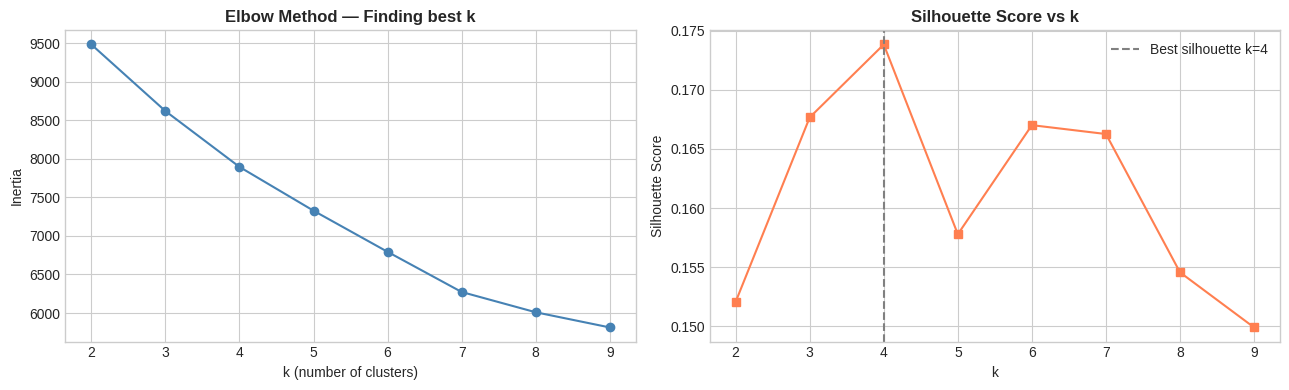

Silhouette scores by k:
  k=2: 0.152
  k=3: 0.168
  k=4: 0.174
  k=5: 0.158
  k=6: 0.167
  k=7: 0.166
  k=8: 0.155
  k=9: 0.150
Highest silhouette score occurs at k=4.
For the final patient segmentation, k=3 is retained because it gives a simple three-group interpretation; this choice is reported as a modelling decision rather than claiming that silhouette also selects k=3.


In [17]:
# Finding the best number of clusters using Elbow Method + Silhouette Score
inertia_vals = []
silhouette_vals = []
k_range = range(2, 10)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels_temp = km_temp.fit_predict(X_pca)
    inertia_vals.append(km_temp.inertia_)
    silhouette_vals.append(silhouette_score(X_pca, labels_temp))

best_k_by_silhouette = list(k_range)[int(np.argmax(silhouette_vals))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_range, inertia_vals, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Finding best k', fontweight='bold')
axes[0].set_xlabel('k (number of clusters)'); axes[0].set_ylabel('Inertia')
axes[1].plot(k_range, silhouette_vals, marker='s', color='coral')
axes[1].axvline(best_k_by_silhouette, color='gray', linestyle='--', label=f'Best silhouette k={best_k_by_silhouette}')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
plt.tight_layout(); plt.show()

print('Silhouette scores by k:')
for k, s in zip(k_range, silhouette_vals):
    print(f'  k={k}: {s:.3f}')
print(f'Highest silhouette score occurs at k={best_k_by_silhouette}.')
print('For the final patient segmentation, k=3 is retained because it gives a simple three-group interpretation; this choice is reported as a modelling decision rather than claiming that silhouette also selects k=3.')


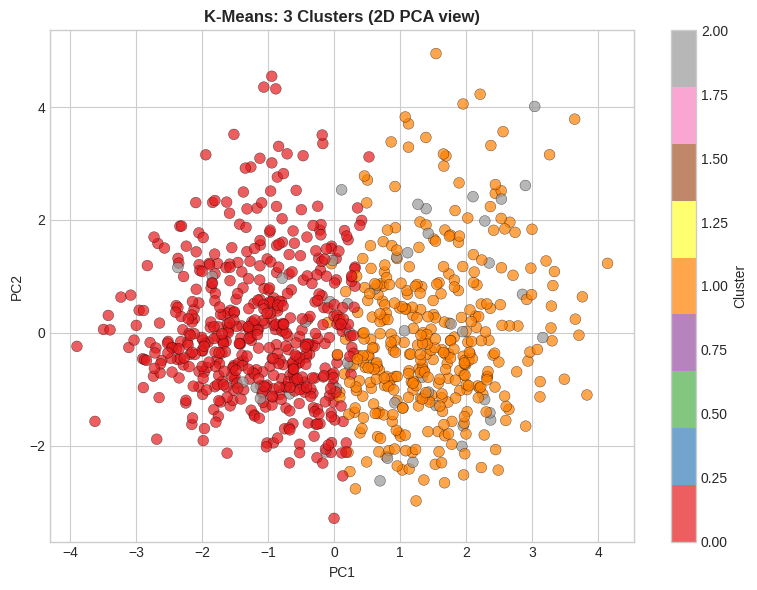

Cluster 0: 508 patients
Cluster 1: 364 patients
Cluster 2: 46 patients


In [18]:
# Running K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=kmeans_labels,
                      cmap='Set1', alpha=0.7, edgecolors='black', linewidths=0.3, s=60)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means: 3 Clusters (2D PCA view)', fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout(); plt.show()

for lbl in sorted(set(kmeans_labels)):
    print(f'Cluster {lbl}: {list(kmeans_labels).count(lbl)} patients')

### Algorithm 2 — Agglomerative (Hierarchical) Clustering

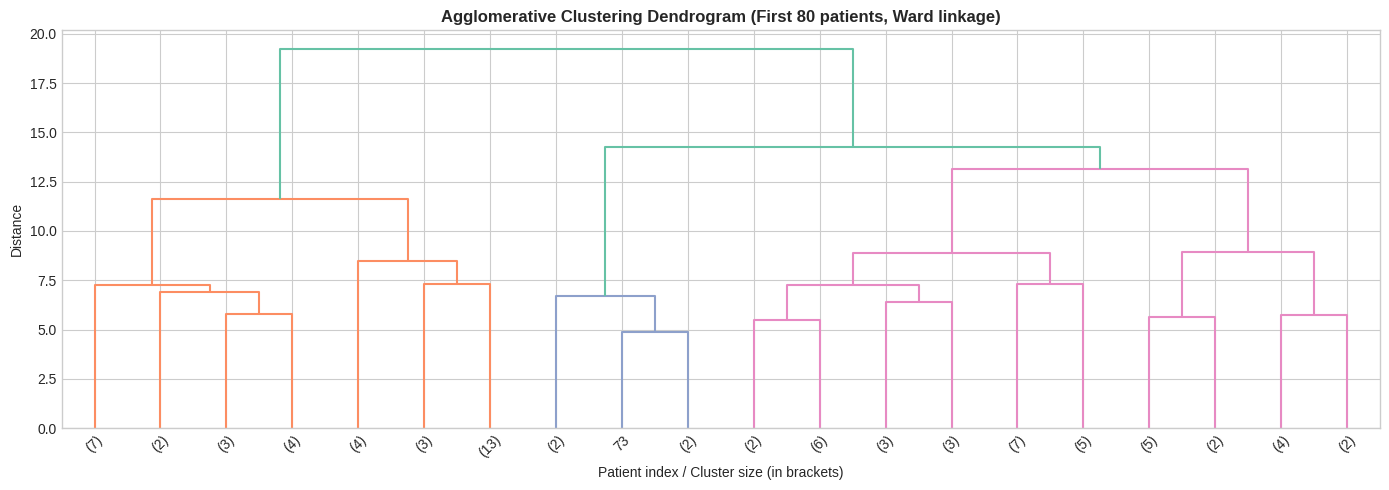

Observation: 3 major branches are visible, which confirms k=3 is a good choice.


In [19]:
# Dendrogram — shows how patients get merged step by step
# Using only 80 patients so the chart stays readable
linkage_matrix = linkage(X_pca[:80], method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Agglomerative Clustering Dendrogram (First 80 patients, Ward linkage)', fontweight='bold')
plt.xlabel('Patient index / Cluster size (in brackets)')
plt.ylabel('Distance')
plt.tight_layout(); plt.show()
print('Observation: 3 major branches are visible, which confirms k=3 is a good choice.')

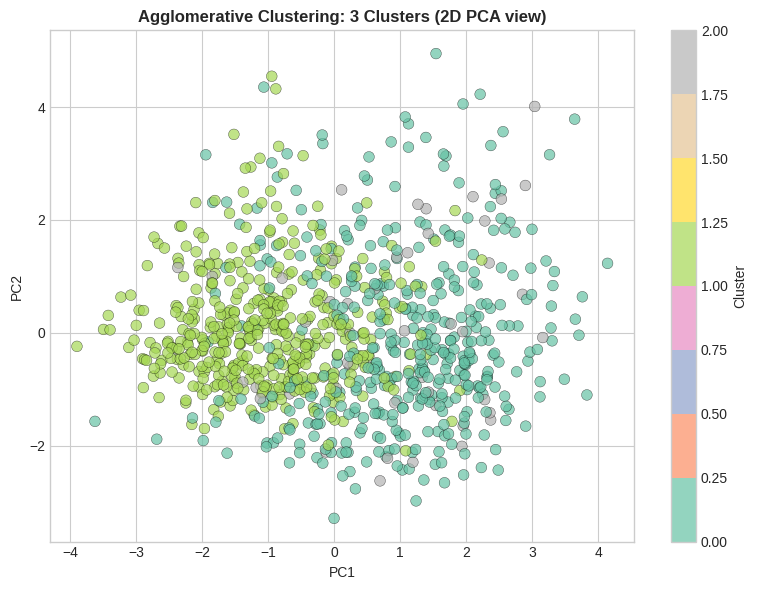

In [20]:
# Running Agglomerative Clustering with 3 clusters
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=agglo_labels,
                      cmap='Set2', alpha=0.7, edgecolors='black', linewidths=0.3, s=60)
plt.colorbar(scatter, label='Cluster')
plt.title('Agglomerative Clustering: 3 Clusters (2D PCA view)', fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout(); plt.show()

### Algorithm 3 — DBSCAN

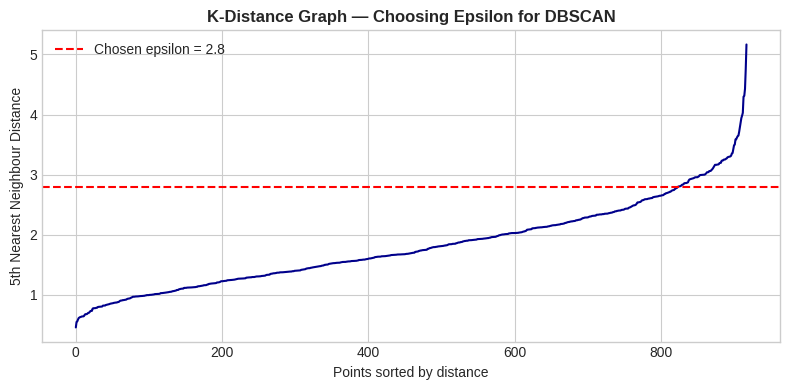

Chosen epsilon = 2.8. This value gives a much more useful DBSCAN result than eps=1.2 on this dataset.


In [21]:
# DBSCAN needs an epsilon value (maximum neighbourhood distance).
# The 5-nearest-neighbour distance curve is used to identify a reasonable elbow.
# For this dataset, the useful elbow is around eps = 2.8.

nn = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
sorted_dist = np.sort(distances[:, 4])

dbscan_eps = 2.8

plt.figure(figsize=(8, 4))
plt.plot(sorted_dist, color='darkblue')
plt.axhline(y=dbscan_eps, color='red', linestyle='--', label=f'Chosen epsilon = {dbscan_eps}')
plt.title('K-Distance Graph — Choosing Epsilon for DBSCAN', fontweight='bold')
plt.xlabel('Points sorted by distance'); plt.ylabel('5th Nearest Neighbour Distance')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Chosen epsilon = {dbscan_eps}. This value gives a much more useful DBSCAN result than eps=1.2 on this dataset.')


Clusters found: 3
Noise points: 41 (4.5%)
DBSCAN cluster sizes (excluding noise):
0    848
1     24
2      5
Name: count, dtype: int64


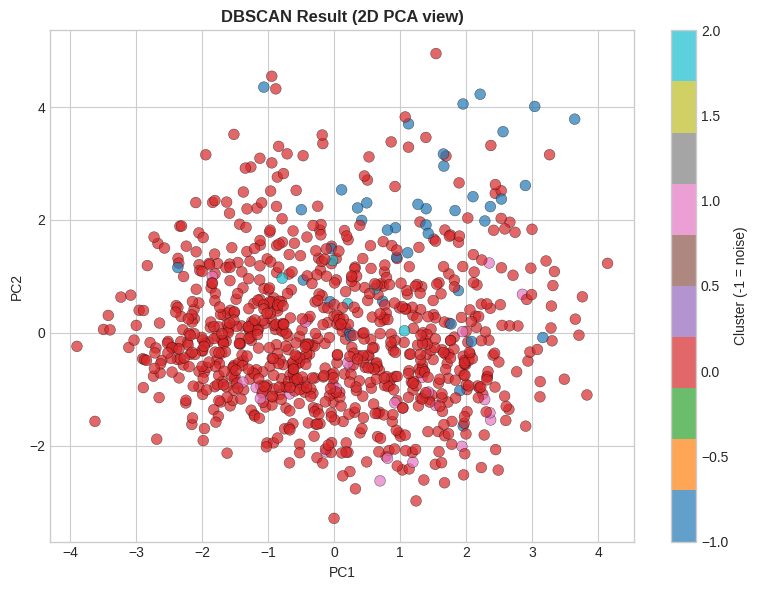

In [22]:
# Running DBSCAN
# Points labelled -1 are noise (do not fit into any cluster).
dbscan = DBSCAN(eps=dbscan_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(np.sum(dbscan_labels == -1))
print(f'Clusters found: {n_clusters_db}')
print(f'Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)')
print('DBSCAN cluster sizes (excluding noise):')
print(pd.Series(dbscan_labels[dbscan_labels != -1]).value_counts().sort_index())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=dbscan_labels,
                      cmap='tab10', alpha=0.7, edgecolors='black', linewidths=0.3, s=60)
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.title('DBSCAN Result (2D PCA view)', fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout(); plt.show()


---
## Section 9 — Model Evaluation & Comparison

In [23]:
# Comparing all 3 algorithms
def get_scores(labels, X, name):
    mask = labels != -1  # skip noise when evaluating DBSCAN
    n_clusters = len(set(labels[mask]))
    noise = int((~mask).sum())
    if n_clusters < 2:
        return {'Algorithm': name, 'Clusters': n_clusters, 'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Noise': noise}
    sil = round(silhouette_score(X[mask], labels[mask]), 3)
    db = round(davies_bouldin_score(X[mask], labels[mask]), 3)
    return {'Algorithm': name, 'Clusters': n_clusters, 'Silhouette': sil, 'Davies-Bouldin': db, 'Noise': noise}

scores_df = pd.DataFrame([
    get_scores(kmeans_labels, X_pca, 'K-Means (k=3)'),
    get_scores(agglo_labels, X_pca, 'Agglomerative (k=3)'),
    get_scores(dbscan_labels, X_pca, f'DBSCAN (eps={dbscan_eps})'),
])

print('=== Model Evaluation Comparison ===')
print(scores_df.to_string(index=False))
print('\nHigher Silhouette = better | Lower Davies-Bouldin = better')
print('\nInterpretation: DBSCAN has stronger internal scores, but its clusters are highly imbalanced; K-Means gives more usable patient-group sizes for interpretation.')


=== Model Evaluation Comparison ===
          Algorithm  Clusters  Silhouette  Davies-Bouldin  Noise
      K-Means (k=3)         3       0.168           1.916      0
Agglomerative (k=3)         3       0.130           2.277      0
   DBSCAN (eps=2.8)         3       0.272           1.205     41

Higher Silhouette = better | Lower Davies-Bouldin = better

Interpretation: DBSCAN has stronger internal scores, but its clusters are highly imbalanced; K-Means gives more usable patient-group sizes for interpretation.


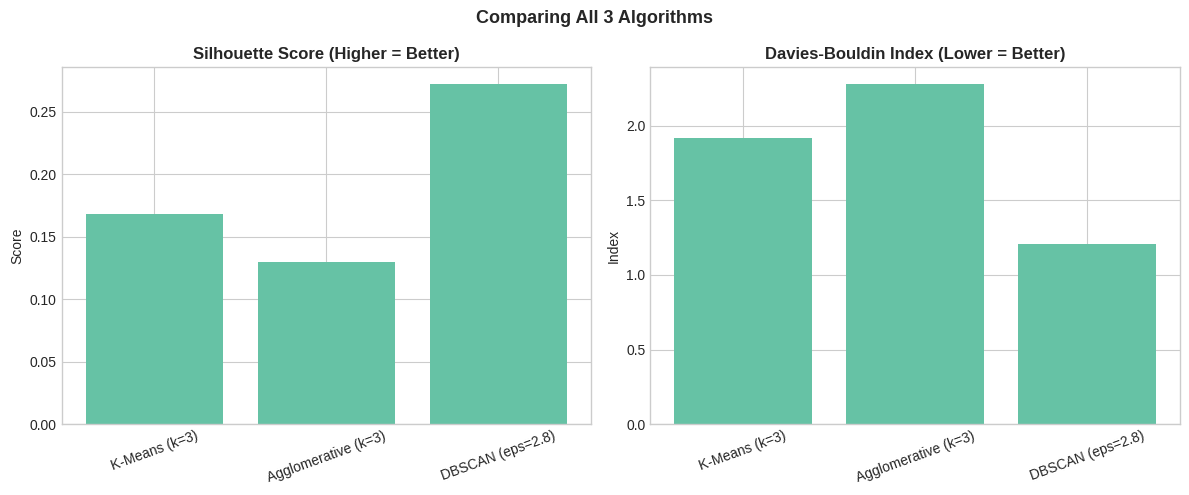

In [24]:
# Bar chart comparison
num_df = scores_df.dropna(subset=['Silhouette', 'Davies-Bouldin']).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(num_df['Algorithm'], num_df['Silhouette'])
axes[0].set_title('Silhouette Score (Higher = Better)', fontweight='bold'); axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(num_df['Algorithm'], num_df['Davies-Bouldin'])
axes[1].set_title('Davies-Bouldin Index (Lower = Better)', fontweight='bold'); axes[1].set_ylabel('Index')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('Comparing All 3 Algorithms', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Section 10 — Cluster Interpretation

In [25]:
# What does each K-Means cluster look like?
# The target/disease severity is NOT used to train K-Means. It is added only now
# for post-hoc interpretation of the discovered clusters.
df_profile = df_clean.copy()
df_profile['Cluster'] = kmeans_labels
df_profile['Actual_Severity'] = target_col.values

summary = df_profile.groupby('Cluster')[['age','trestbps','chol','thalach','oldpeak','exang','Actual_Severity']].mean().round(2)
print('Average values per cluster:')
print(summary)
print('\nCluster sizes:')
print(df_profile['Cluster'].value_counts().sort_index())

# Rank clusters by observed average disease severity for post-hoc interpretation.
risk_order = summary['Actual_Severity'].sort_values().index.tolist()
risk_labels = {
    risk_order[0]: 'LOWER observed severity',
    risk_order[1]: 'INTERMEDIATE observed severity',
    risk_order[2]: 'HIGHER observed severity'
}
print('\nPost-hoc interpretation based on average observed disease severity:')
for cluster in summary.index:
    print(f'Cluster {cluster}: {risk_labels[cluster]} (mean severity={summary.loc[cluster, "Actual_Severity"]:.2f})')


Average values per cluster:
           age  trestbps    chol  thalach  oldpeak  exang  Actual_Severity
Cluster                                                                   
0        50.36    127.83  216.12   149.21     0.38   0.07             0.48
1        57.81    137.08  195.62   122.34     1.47   0.78             1.65
2        54.35    132.48  193.18   132.17     0.98   0.41             1.52

Cluster sizes:
Cluster
0    508
1    364
2     46
Name: count, dtype: int64

Post-hoc interpretation based on average observed disease severity:
Cluster 0: LOWER observed severity (mean severity=0.48)
Cluster 1: HIGHER observed severity (mean severity=1.65)
Cluster 2: INTERMEDIATE observed severity (mean severity=1.52)


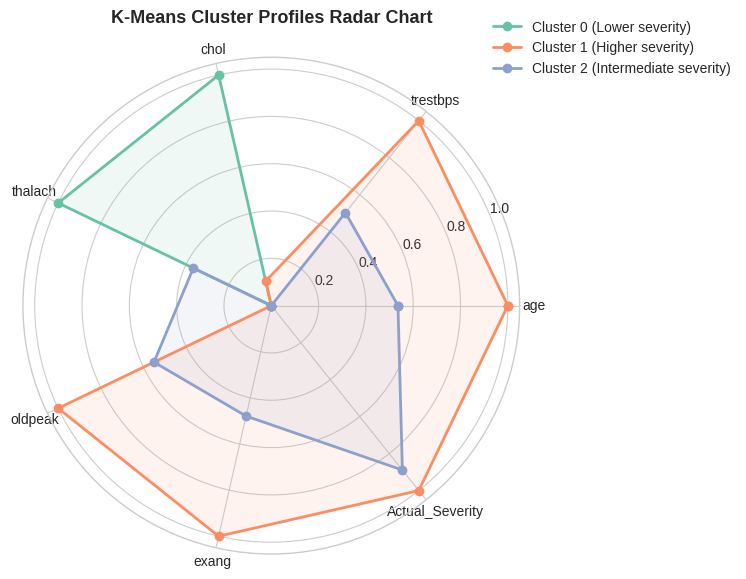

Cluster 0: Lower severity (mean observed severity = 0.48)
Cluster 1: Higher severity (mean observed severity = 1.65)
Cluster 2: Intermediate severity (mean observed severity = 1.52)


In [26]:
# Radar chart to compare K-Means clusters visually
radar_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'exang', 'Actual_Severity']
norm = (summary[radar_features] - summary[radar_features].min()) / (summary[radar_features].max() - summary[radar_features].min())

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Assign labels from the actual post-hoc severity ranking rather than assuming
# that numeric cluster IDs correspond to risk levels.
risk_order = summary['Actual_Severity'].sort_values().index.tolist()
risk_names = {
    risk_order[0]: 'Lower severity',
    risk_order[1]: 'Intermediate severity',
    risk_order[2]: 'Higher severity'
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cluster in summary.index:
    row = norm.loc[cluster].values
    vals = list(row) + [row[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, label=f'Cluster {cluster} ({risk_names[cluster]})')
    ax.fill(angles, vals, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=10)
ax.set_title('K-Means Cluster Profiles Radar Chart', fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1))
plt.tight_layout(); plt.show()

for cluster in summary.index:
    print(f'Cluster {cluster}: {risk_names[cluster]} (mean observed severity = {summary.loc[cluster, "Actual_Severity"]:.2f})')


---
## Section 11 — Final Model Selection

In [27]:
print(f"""
FINAL MODEL: K-Means with k=3

Why I picked K-Means:
  1. It produces three reasonably interpretable patient groups with no noise points.
  2. Its cluster sizes are substantially more balanced than the DBSCAN result.
  3. Agglomerative clustering gives a very similar but slightly weaker internal evaluation.
  4. DBSCAN has better internal scores after tuning, but its 3 clusters are highly imbalanced
     (one very large cluster and very small clusters), which makes it less useful for patient segmentation.
  5. k=3 is retained as a simple modelling choice for low/intermediate/high observed-severity comparison;
     the silhouette analysis itself peaks at a different k, so this is not presented as a perfect metric optimum.

Important: The disease-severity label was NOT used during clustering. It is only used after clustering
to interpret the discovered groups. These groups should not be treated as medical diagnoses.
""")



FINAL MODEL: K-Means with k=3

Why I picked K-Means:
  1. It produces three reasonably interpretable patient groups with no noise points.
  2. Its cluster sizes are substantially more balanced than the DBSCAN result.
  3. Agglomerative clustering gives a very similar but slightly weaker internal evaluation.
  4. DBSCAN has better internal scores after tuning, but its 3 clusters are highly imbalanced
     (one very large cluster and very small clusters), which makes it less useful for patient segmentation.
  5. k=3 is retained as a simple modelling choice for low/intermediate/high observed-severity comparison;
     the silhouette analysis itself peaks at a different k, so this is not presented as a perfect metric optimum.

Important: The disease-severity label was NOT used during clustering. It is only used after clustering
to interpret the discovered groups. These groups should not be treated as medical diagnoses.



---
## Section 12 — Conclusion & Recommendations

In [28]:
print(f"""
CONCLUSION
==========
In this assignment, I applied K-Means, Agglomerative Clustering, and DBSCAN
to the 920-row UCI Heart Disease dataset. After removing 2 duplicate rows,
918 patient records and 13 clinical features were used for clustering.

K-Means with k=3 was selected as the final model because it produced three
reasonably sized, interpretable groups without noise points. Its internal
metrics were modest (Silhouette = {scores_df.loc[scores_df['Algorithm']=='K-Means (k=3)', 'Silhouette'].iloc[0]:.3f}),
so the result should be viewed as exploratory rather than as a highly separated clustering solution.

Post-hoc comparison with the held-out disease-severity label showed that the
clusters differ in their average observed severity. Cluster labels are therefore
interpreted according to their observed severity ranking, rather than assuming
that Cluster 0/1/2 automatically means low/moderate/high risk.

RECOMMENDATIONS
===============
  - The lower-severity cluster can be described as having comparatively healthier
    observed clinical characteristics in this dataset.
  - The intermediate-severity cluster shows a greater concentration of warning signs
    and can be investigated further in a clinical context.
  - The higher-severity cluster contains patients with comparatively higher observed
    disease severity and should be considered a group for further clinical investigation.
  - These clusters are exploratory ML groupings, not medical diagnoses or treatment recommendations.
  - DBSCAN noise/outlier points should be investigated as unusual observations rather than
    automatically treated as high-risk patients.
""")



CONCLUSION
In this assignment, I applied K-Means, Agglomerative Clustering, and DBSCAN
to the 920-row UCI Heart Disease dataset. After removing 2 duplicate rows,
918 patient records and 13 clinical features were used for clustering.

K-Means with k=3 was selected as the final model because it produced three
reasonably sized, interpretable groups without noise points. Its internal
metrics were modest (Silhouette = 0.168),
so the result should be viewed as exploratory rather than as a highly separated clustering solution.

Post-hoc comparison with the held-out disease-severity label showed that the
clusters differ in their average observed severity. Cluster labels are therefore
interpreted according to their observed severity ranking, rather than assuming
that Cluster 0/1/2 automatically means low/moderate/high risk.

RECOMMENDATIONS
  - The lower-severity cluster can be described as having comparatively healthier
    observed clinical characteristics in this dataset.
  - The intermedia

---
## Section 13 — Limitations & Future Work

In [29]:
print("""
LIMITATIONS
===========
  1. The dataset contains 920 records from multiple hospital sources, but only 918 unique rows were
     used after duplicate removal.
  2. The dataset has demographic imbalance (approximately 68% male), so the clusters may not
     represent all patient populations equally well.
  3. K-Means assumes relatively compact/spherical clusters, which may not fully describe medical data.
  4. The best K-Means silhouette score is below the 0.2 target, indicating that the discovered groups
     are only moderately separated.
  5. PCA improves dimensionality for clustering but reduces direct interpretability of the original features.
  6. Disease severity was deliberately excluded from training, but comparing clusters with severity after
     training does not prove that the clusters are clinically valid.

FUTURE WORK
===========
  1. Test Gaussian Mixture Models (GMM) for soft/probabilistic cluster assignments.
  2. Compare PCA with UMAP or t-SNE for non-linear structure exploration.
  3. Tune DBSCAN using a systematic epsilon/min_samples search and assess cluster balance alongside
     internal metrics.
  4. Add clinically relevant features where available and validate the clusters with domain experts.
  5. Use repeated stability analysis or bootstrapping to check whether the clusters are reproducible.
""")



LIMITATIONS
  1. The dataset contains 920 records from multiple hospital sources, but only 918 unique rows were
     used after duplicate removal.
  2. The dataset has demographic imbalance (approximately 68% male), so the clusters may not
     represent all patient populations equally well.
  3. K-Means assumes relatively compact/spherical clusters, which may not fully describe medical data.
  4. The best K-Means silhouette score is below the 0.2 target, indicating that the discovered groups
     are only moderately separated.
  5. PCA improves dimensionality for clustering but reduces direct interpretability of the original features.
  6. Disease severity was deliberately excluded from training, but comparing clusters with severity after
     training does not prove that the clusters are clinically valid.

FUTURE WORK
  1. Test Gaussian Mixture Models (GMM) for soft/probabilistic cluster assignments.
  2. Compare PCA with UMAP or t-SNE for non-linear structure exploration.
  3. Tune